### **Load Dependencies**

In [21]:
import time
from prompts import *
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
from IPython.display import Markdown, display, Image

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

- **Load Docs**

In [2]:
docs = (
    PyPDFLoader("./docs/Company_Policies.pdf").load()
    + PyPDFLoader("./docs/Company_Profile.pdf").load()
    + PyPDFLoader("./docs/Product_and_Pricing.pdf").load()
)

- **Split Docs into Chunks**

In [3]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

- **Embed Chunks and Create Retriever**

In [4]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

- **Create LLM**

In [5]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

### **Graph Building**

- **Graph State**

In [26]:
class State(TypedDict):
    question: str
    answer: str
    need_retrieval: Literal[True, False]
    docs: List[Document]

#### **Decide Retrieval Node**
- Decide whether retrieval is necessary for answering the question

In [27]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="Whether the agent should perform retrieval to answer the question."
    )

In [28]:
def decide_retrieval(state: State) -> dict:
    """ This function uses the LLM to decide whether retrieval is necessary to answer the question."""

    should_retrieve_llm = llm.with_structured_output(RetrieveDecision)
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_prompt(question=state["question"])
    )
    
    return { "need_retrieval" : decision.should_retrieve }

In [29]:
decision = decide_retrieval({"question": "What is the company policy?"})
decision

{'need_retrieval': True}

#### **Generate Answer**
- Generate a direct answer to the question.

In [30]:
def generate_direct(state: State) -> dict:
    """ This function uses the LLM to generate a direct answer to the question."""

    answer = llm.invoke(
        direct_generation_prompt.format_prompt(question=state["question"])
    )
    return {"answer": answer.content}

In [31]:
answer = generate_direct({ "question" : "What is Machine Learning?" })['answer']
display(Markdown(answer))

Machine Learning is a subset of artificial intelligence (AI) that focuses on the development of algorithms and statistical models that enable computers to perform tasks without explicit instructions. Instead of being programmed to perform a specific task, machine learning systems learn from data, identifying patterns and making decisions based on that data.

There are several types of machine learning, including:

1. **Supervised Learning**: The model is trained on a labeled dataset, meaning that the input data is paired with the correct output. The model learns to map inputs to outputs and can make predictions on new, unseen data.

2. **Unsupervised Learning**: The model is trained on data without labeled responses. It tries to find hidden patterns or intrinsic structures in the input data, such as clustering similar data points together.

3. **Reinforcement Learning**: The model learns by interacting with an environment and receiving feedback in the form of rewards or penalties. It aims to learn a policy that maximizes cumulative rewards over time.

Machine learning is widely used in various applications, including image and speech recognition, natural language processing, recommendation systems, and autonomous vehicles, among others.

#### **Retrieve Docs**
- Retrieve docs using the retriever

In [32]:
def retrieve(state: State) -> dict:
    """ This function performs retrieval using the retriever and returns the retrieved documents."""
    retrieved_docs = retriever.invoke(state["question"])
    return {"docs": retrieved_docs}

#### **Router**
- If retrieval is needed, perform retrieval. Otherwise, generate a direct answer.

In [33]:
def router(state: State) -> str:
    """ This function routes the state to the appropriate function based on whether retrieval is needed or not."""
    
    if state["need_retrieval"]:
        return "need_retrieval"
    else:
        return "generate_direct"

#### **Graph Building**

In [34]:
# State graph construction
builder = StateGraph(State)

# Adding nodes
builder.add_node("decide_retrieval", decide_retrieval)
builder.add_node("retrieve", retrieve)
builder.add_node("generate_answer", generate_direct)

# Adding edges
builder.add_edge(START, "decide_retrieval")

builder.add_conditional_edges(
    "decide_retrieval", router,
    {
        "need_retrieval": "retrieve",
        "generate_direct": "generate_answer"
    }
)

builder.add_edge("generate_answer", END)
builder.add_edge("retrieve", END)

# Compile the graph
rag = builder.compile()

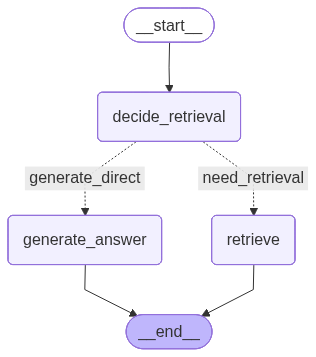

In [35]:
display(Image(rag.get_graph().draw_mermaid_png()))

#### **Test Graph**

In [36]:
result = rag.invoke({
    "question": "What is the company policy on remote work?"
})

In [37]:
result.keys()

dict_keys(['question', 'need_retrieval', 'docs'])

In [38]:
result['need_retrieval']

True

In [41]:
for doc in result['docs']:
    display(Markdown(f"**Source:** {doc.metadata['source']}"))
    display(Markdown(doc.page_content))
    display(Markdown("*"*150))

**Source:** ./docs/Company_Policies.pdf


Sick Leave: 10 working days per year

Casual Leave: 6 working days per year

Maternity Leave: As per statutory norms

Unused annual leave may be carried forward up to 30 days
Workplace Conduct
Employees are expected to act professionally and ethically at all times.

Maintain confidentiality of company and client information

Avoid conflicts of interest

No acceptance of bribes or unethical gifts

Compliance with information security policies
Disciplinary Actions
Any violation of company policies may result in disciplinary action.

******************************************************************************************************************************************************

**Source:** ./docs/Company_Policies.pdf

NexaAI Solutions – Company Policies
HR Policies
NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
All employment decisions are made without discrimination.

Equal opportunity employer

Bi-annual performance reviews

Clear career progression framework

Strict anti-harassment policy
Leave Policy
Employees are encouraged to maintain a healthy work-life balance.

Annual Leave: 18 working days per year

Sick Leave: 10 working days per year

Casual Leave: 6 working days per year

Maternity Leave: As per statutory norms


...

help teams operate with speed, clarity, and confidence.
We focus on practical AI adoption rather than experimental research.
Core Values
Our values guide how we build products, treat customers, and work as a team.

Customer Obsession – Every solution starts with a real business pain point.

Transparency – Clear communication with customers and within teams.

Accountability – Ownership of outcomes, not just tasks.

Security First – Data protection is non-negotiable.

Continuous Improvement – Iterate, learn, and improve relentlessly.

******************************************************************************************************************************************************

**Source:** ./docs/Company_Profile.pdf

and education sectors.

Founded: 2021

Headquarters: Bengaluru, India

Employees: 85+

Operating Regions: India, Southeast Asia, Europe
Vision
To become a trusted AI partner for organizations by enabling intelligent decision-making through
reliable and explainable AI systems.
Mission
Our mission is to simplify access to organizational knowledge, automate repetitive workflows, and
help teams operate with speed, clarity, and confidence.
We focus on practical AI adoption rather than experimental research.
Core Values

******************************************************************************************************************************************************